# Import

In [1]:
from parcels import (
        FieldSet,
        JITParticle,
        ScipyParticle,
        ParticleSet,
        AdvectionRK4,
        AdvectionRK4_3D,
        StatusCode,
)
import parcels

import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import cmocean

import xarray as xr
from glob import glob
import cartopy
import cartopy.crs as ccrs
from time import time
import warnings
import shapely
import itertools

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210101-20210129_dt60min_N43600_seed123.zarr")
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Nested_20210101-20210108_dt60min_N500_seed123.zarr")
ds_trajectories = xr.open_zarr(zarr_path).compute()
ds_trajectories

<xarray.Dataset> Size: 879MB
Dimensions:     (trajectory: 43600, obs: 504)
Coordinates:
  * obs         (obs) int32 2kB 0 1 2 3 4 5 6 7 ... 497 498 499 500 501 502 503
  * trajectory  (trajectory) int64 349kB 0 1 2 3 4 ... 43596 43597 43598 43599
Data variables:
    age_sec     (trajectory, obs) float32 88MB 3.6e+03 7.2e+03 ... nan nan
    cell_ID     (trajectory, obs) float32 88MB 5.111e+04 5.111e+04 ... nan nan
    lat         (trajectory, obs) float64 176MB 57.52 57.52 57.52 ... nan nan
    lon         (trajectory, obs) float64 176MB 16.78 16.78 16.78 ... nan nan
    time        (trajectory, obs) datetime64[ns] 176MB 2021-01-01T06:45:00 .....
    z           (trajectory, obs) float64 176MB 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [3]:
release_area_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
gdf_release_area = gdf_release_area.loc[
        (gdf_release_area.F_vesiculo != 0).values, 
        ["geometry", "CELLCODE"],]

In [4]:
subbasins_lvl2_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/HELCOM_subbasins_2022_level2")
gdf_subbasins_area = gpd.read_file(Path(subbasins_lvl2_path, "HELCOM_subbasins_2022_level2.shp"))
gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=ccrs.Geodetic())

In [5]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_ID"))
except: ds_trajectories

In [6]:
release_centroid = gpd.GeoDataFrame(gdf_release_area.CELLCODE, geometry=gdf_release_area.geometry.centroid)
gdf_release_area = gpd.sjoin_nearest(
        left_df=release_centroid, 
        right_df=gdf_subbasins_area, 
        how="left", 
        rsuffix="basin_",
)[["CELLCODE", "level_2", "geometry"]]

In [7]:
try: list_cell_ID = ds_trajectories.cell_ID.isel(obs=0).values.astype(int)
except: ""

In [8]:
# https://github.com/Yichabod/natural_disaster_pred/blob/master/cropping_coordinates.py

earth_radius = 6271.0
degrees_to_radians = np.pi / 180.0
radians_to_degrees = 180.0 / np.pi

def dlat_to_dkm(dlat):
        return dlat * earth_radius * degrees_to_radians
def dlon_to_dkm(latitude, dlon):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dlon * r * degrees_to_radians

In [9]:
dlat = ds_trajectories.lat.diff(dim="obs").interp_like(ds_trajectories.lat)
dlon = ds_trajectories.lon.diff(dim="obs").interp_like(ds_trajectories.lat)
lats = ds_trajectories.lat - dlat / 2

distance = (dlat_to_dkm(dlat)**2 + dlon_to_dkm(lats, dlon)**2)**.5
cumulative_distance = distance.cumsum(dim="obs")
total_distance = distance.sum(dim="obs")

In [10]:
distance = distance.assign_attrs(dict(
        long_name="Distance traveled in kilometers",
        standard_name="Distance",
        units="km",
))
cumulative_distance = cumulative_distance.assign_attrs(dict(
        long_name="Cumulated distance traveled in kilometers",
        standard_name="Cumulated Distance",
        units="km",
))
total_distance = total_distance.assign_attrs(dict(
        long_name="Total distance traveled in kilometers",
        standard_name="Total Distance",
        units="km",
))

In [11]:
release_dates = ds_trajectories.time.where("obs"==0, ds_trajectories.time.isel(obs=0))
valid_obs_count = ds_trajectories.lat.notnull().sum(dim="obs", skipna=True)

In [12]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int)
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

last_lon = last_step.lon
last_lat = last_step.lat

# last_step.to_dataframe()[["lat", "lon", "lat_diff", "lon_diff", "obs", "release_date", "age_sec"]].describe()

In [13]:
first_lat = ds_trajectories.isel(obs=0).lat
first_lon = ds_trajectories.isel(obs=0).lon

traj_dead = ds_trajectories.where(first_lon == last_lon, drop=True)
traj_moving = ds_trajectories.where(first_lon != last_lon, drop=True)
# ds_trajectories = ds_trajectories.where(first_lon != last_lon, drop=True)

In [14]:
lon_diff = last_lon - first_lon
lat_diff = last_lat - first_lat

In [15]:
ds_trajectories = ds_trajectories.assign(
        distance=distance,
        cumulative_distance=cumulative_distance,
        total_distance=total_distance,
        release_date=release_dates,
        valid_obs_count=valid_obs_count,
        lat_diff=lat_diff,
        lon_diff=lon_diff,
)

In [16]:
cell_codes = gdf_release_area.loc[list_cell_ID].CELLCODE.values.flatten().astype(str)
subbasins = gdf_release_area.loc[list_cell_ID].level_2.values.flatten().astype(str)
trajectories = ds_trajectories.trajectory.values
multi_idx_traj_cellID = pd.MultiIndex.from_arrays(
        arrays=[trajectories, list_cell_ID, subbasins, ],
        names=("trajectory_ID", "cell_ID", "subbasin",),
)
traj_coords = xr.Coordinates.from_pandas_multiindex(multi_idx_traj_cellID, "trajectory")

age_sec_obs = ds_trajectories.age_sec.max(dim="trajectory", skipna=True).values

In [17]:
ds_trajectories = ds_trajectories.assign(dict(
        # traj_coords,
        cell_code=("trajectory", cell_codes),
        age_sec_obs=("obs", age_sec_obs),
        subbasin=("trajectory", subbasins),
        cell_ID=("trajectory", list_cell_ID),
        # trajectory_ID=("trajectory", trajectories),
))

In [18]:
lon_min, lon_max = (9,30)
lat_min, lat_max = (52,66)
lon_range = lon_max-lon_min
lat_range = lat_max-lat_min

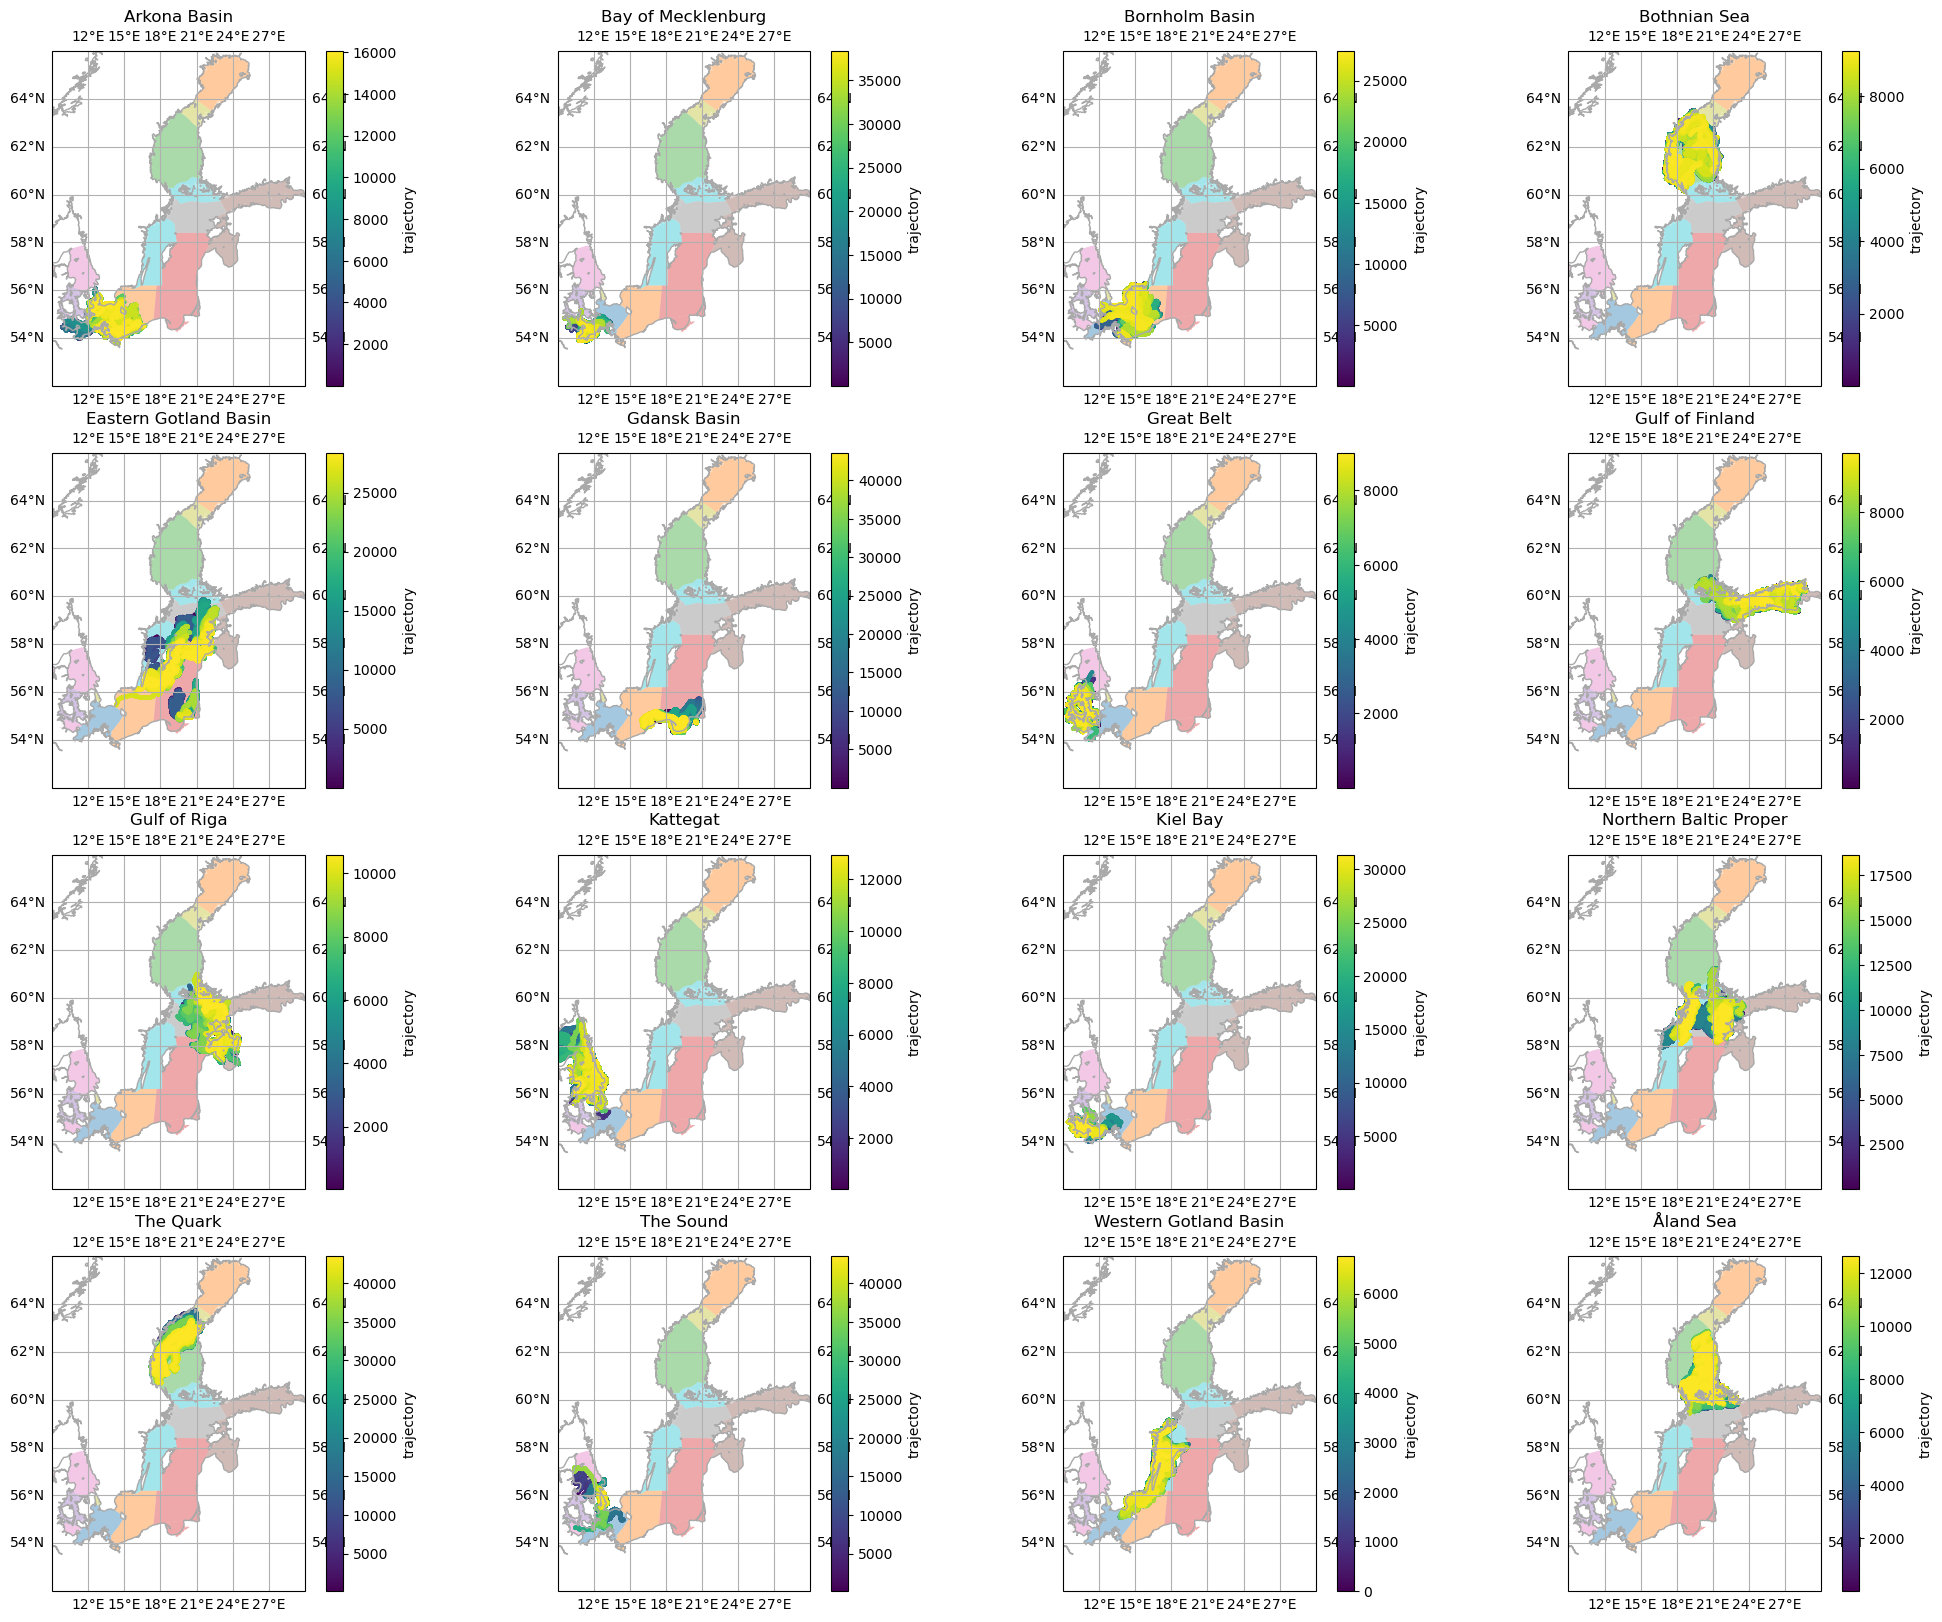

In [62]:
fig = plt.figure(figsize=(25,20))
axes = fig.subplots(nrows=4, ncols=4, subplot_kw={'projection': ccrs.PlateCarree()})
for ax, (sb_name, ds_sb) in zip(axes.flatten(), ds_a.groupby("subbasin")):
        gdf_subbasins_area.plot(ax=ax, column="level_2", alpha=.4, transform=ccrs.Geodetic())
        ds_sb.isel(trajectory=slice(1000)).plot.scatter(
                x="lon", y="lat",
                hue="trajectory",
                s=10,
                edgecolor="none",
                ax=ax,
        )
        ax.set_title(sb_name)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=True)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

statistics of in which month and from which starting position do the particles travel how far, and the area

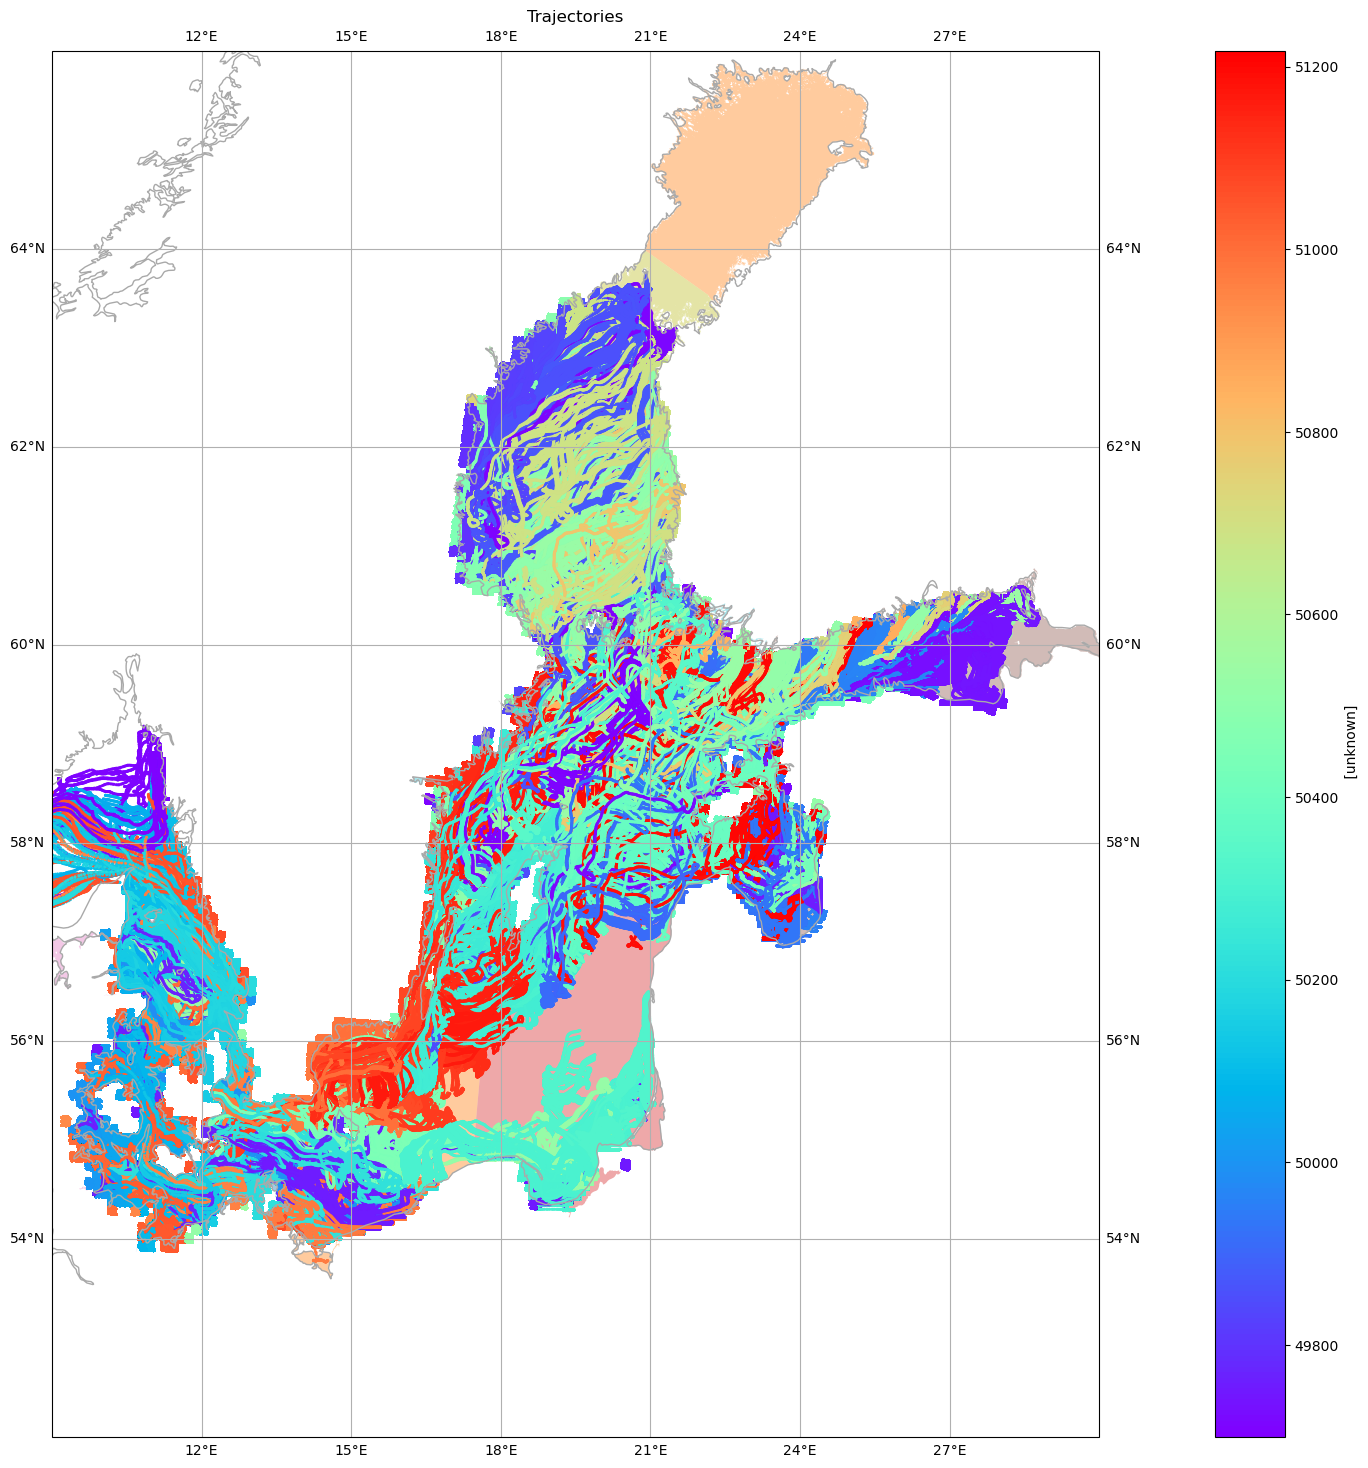

In [ ]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
gdf_subbasins_area.plot(ax=ax, column="level_2", alpha=.4, transform=ccrs.Geodetic())
ds_trajectories.plot.scatter(x="lon", y="lat", hue="cell_ID", cmap="rainbow", s=1, edgecolor="none",)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

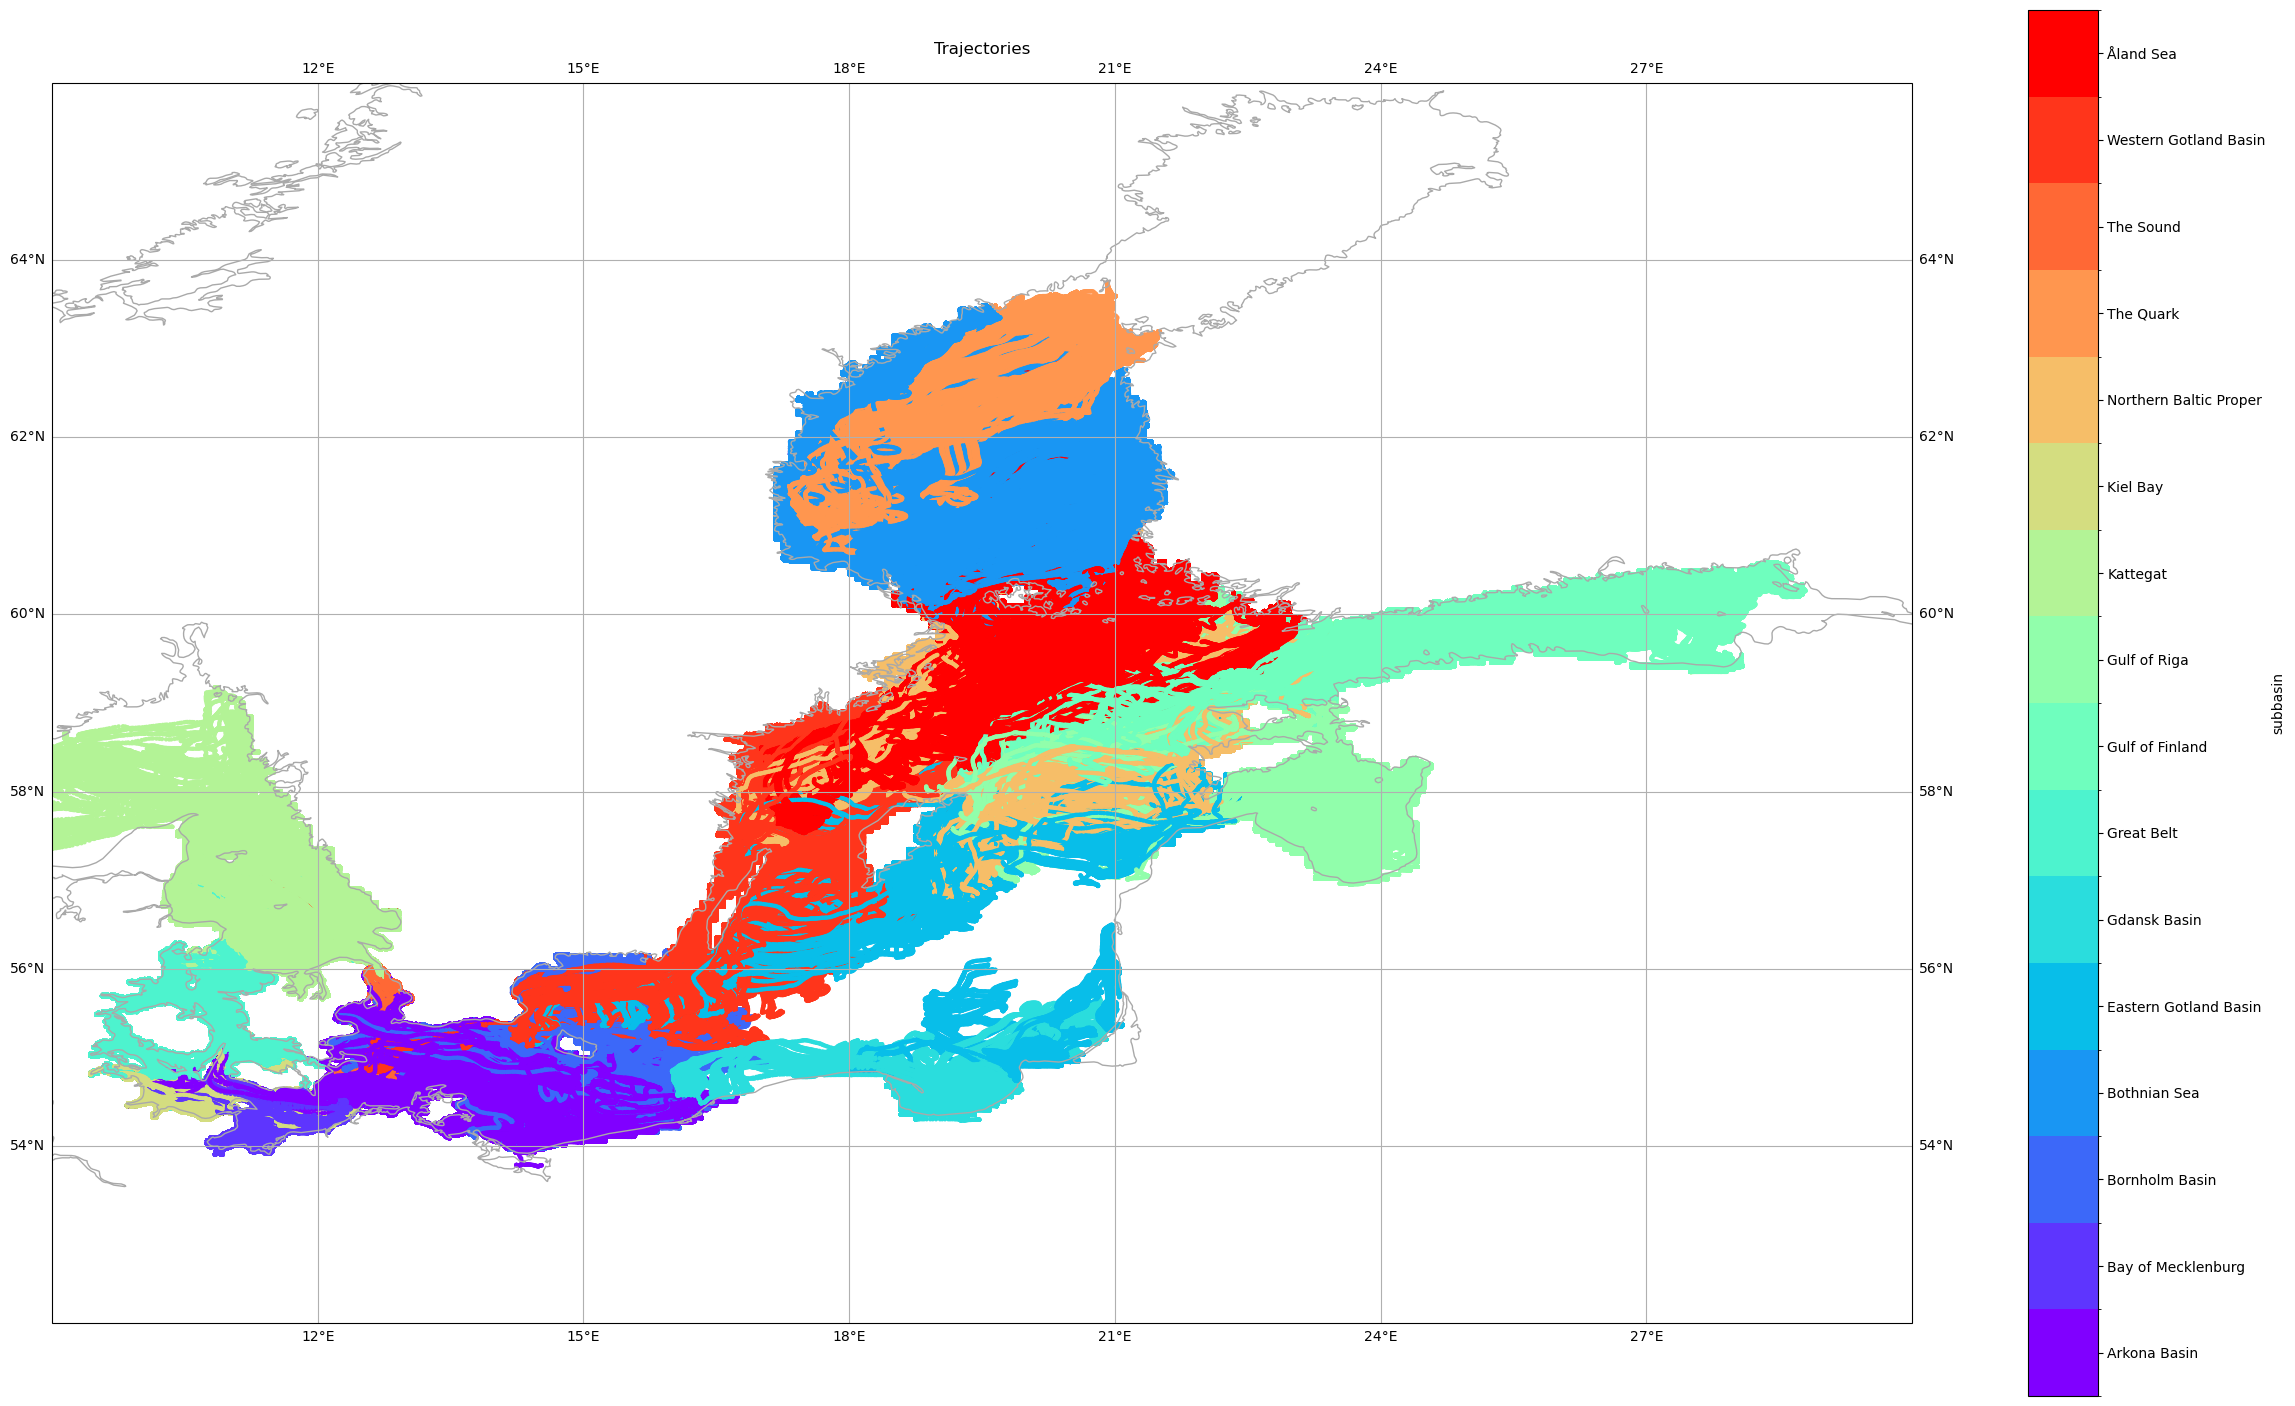

In [ ]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ds_trajectories.plot.scatter(x="lon", y="lat", hue="subbasin", cmap="rainbow", s=10, edgecolor="none",)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

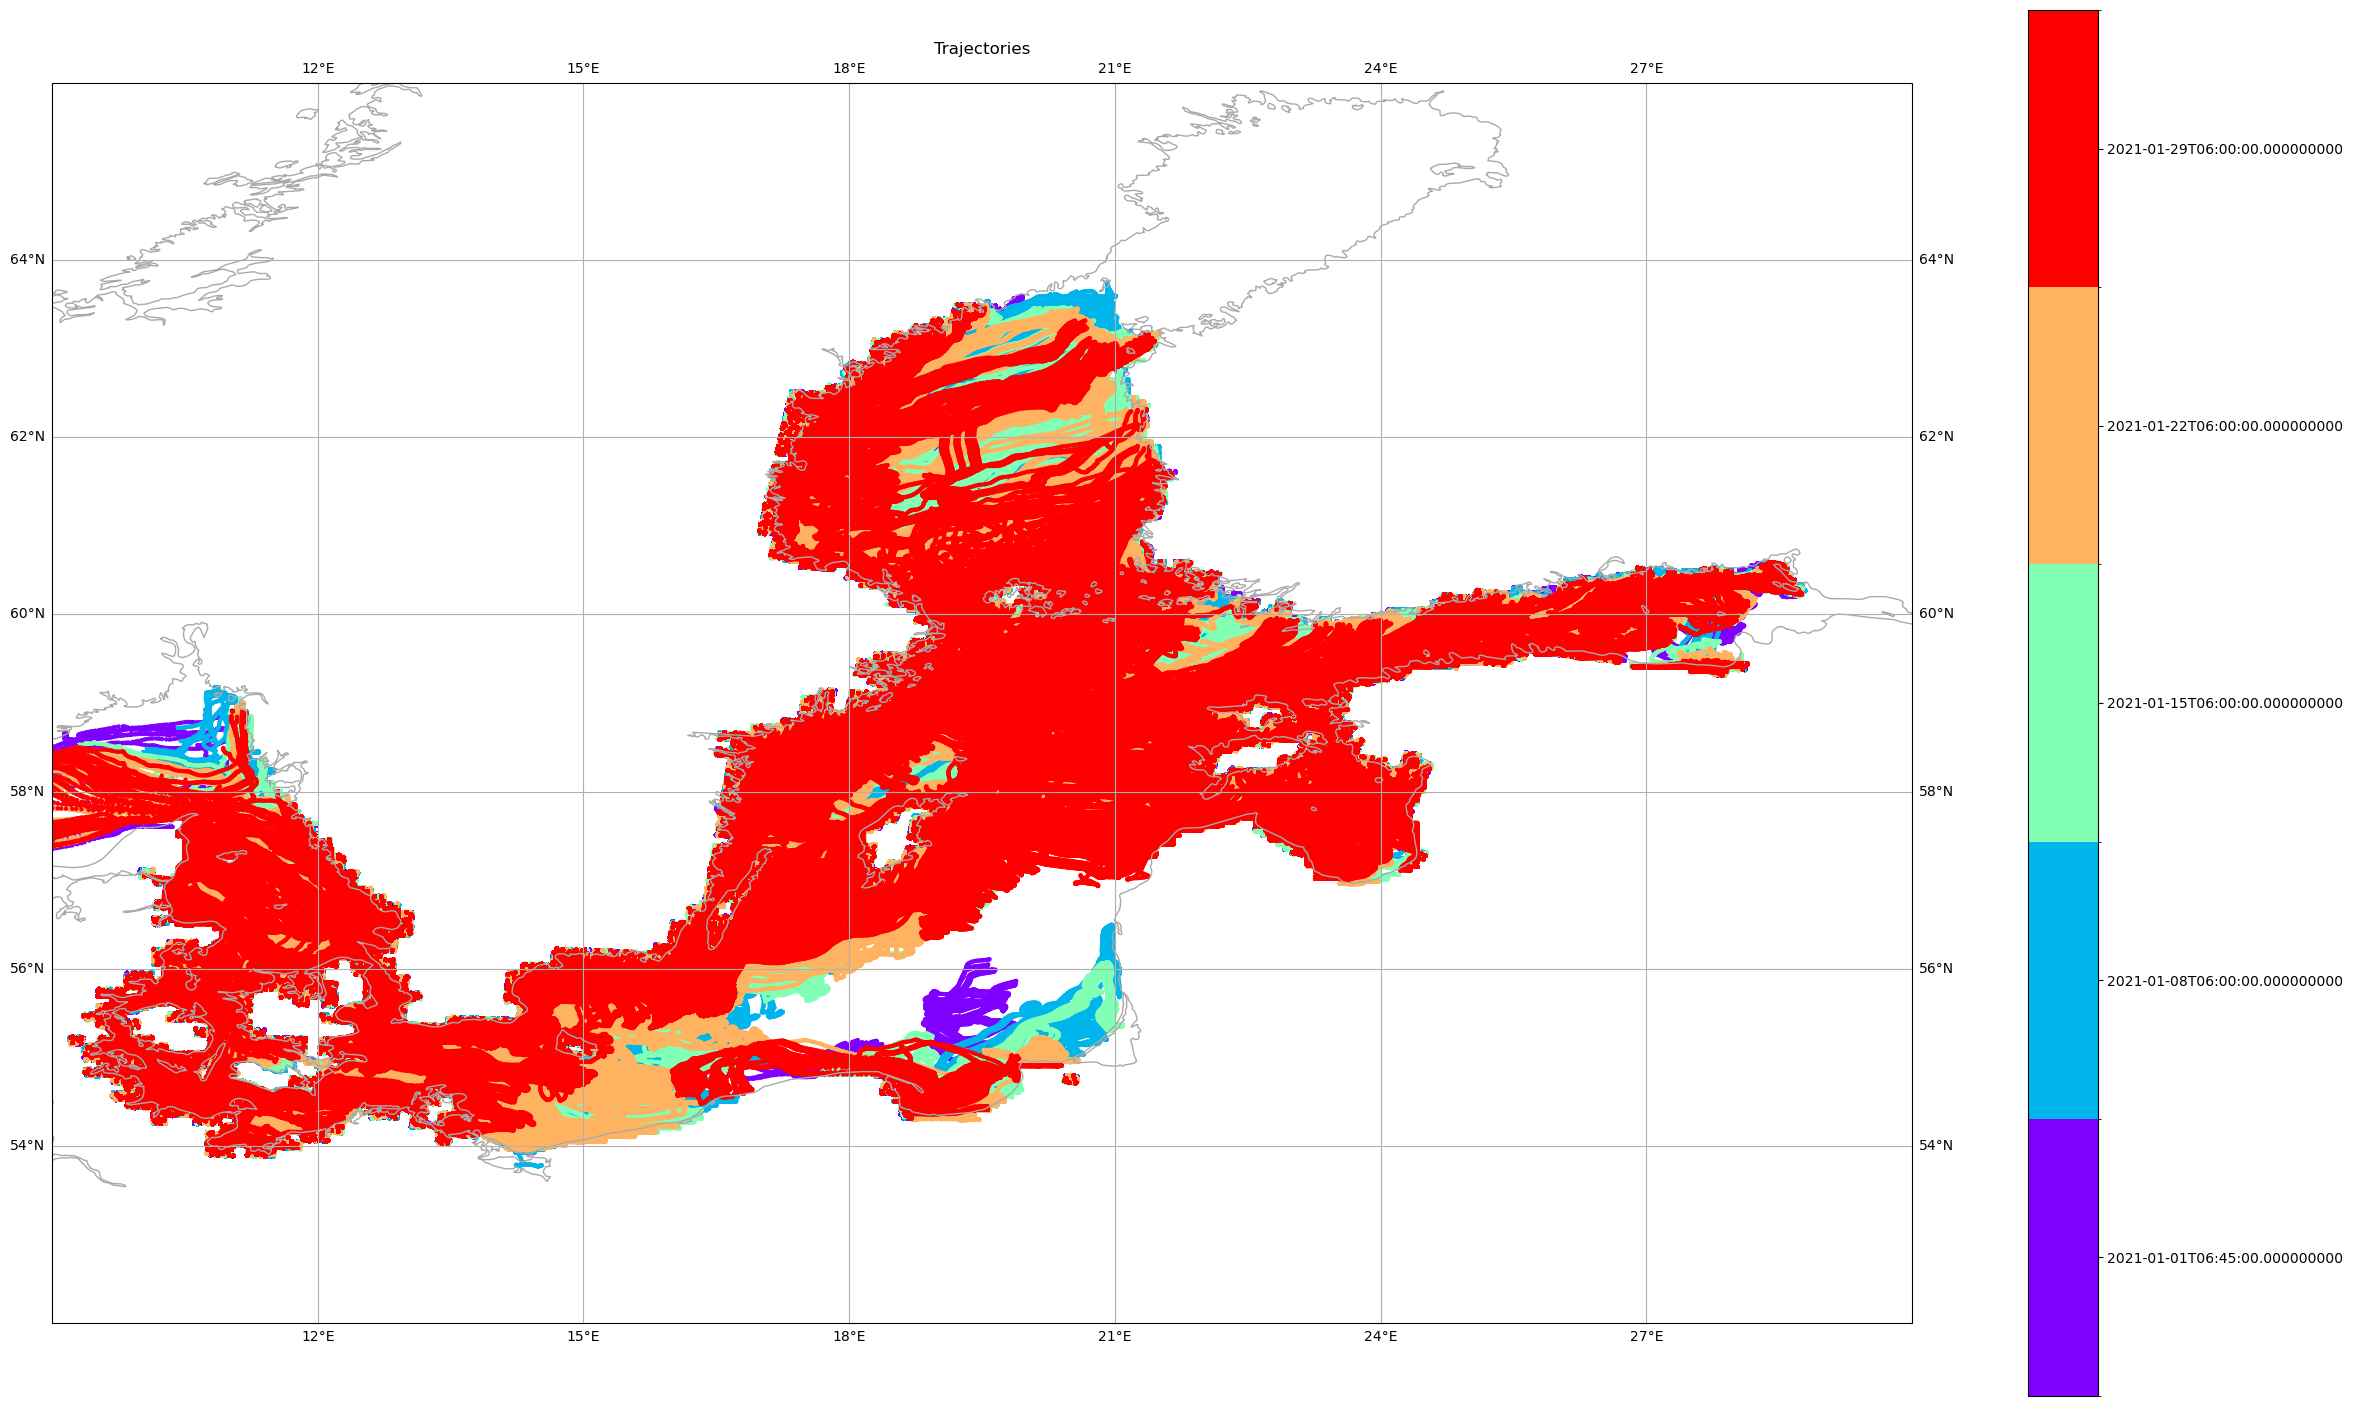

In [22]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ds_trajectories.plot.scatter(x="lon", y="lat", hue="release_date", cmap="rainbow", s=10, edgecolor="none",)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

Maybe also luftlinie distance for each step?

In [19]:
lats = ds_trajectories.isel(obs=0).lat + lat_diff / 2
direct_distance_lat = dlat_to_dkm(lat_diff)
direct_distance_lon = dlon_to_dkm(lon_diff, lats)
direct_distance = (direct_distance_lat**2 + direct_distance_lon**2)**.5

In [20]:
df = ds_trajectories.to_dataframe().reset_index("obs").set_index(["subbasin", "obs"])[["cumulative_distance", "total_distance"]]

<Axes: xlabel='obs', ylabel='cumulative_distance'>

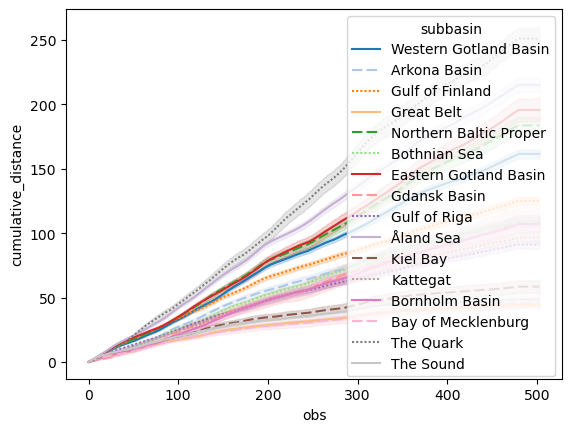

In [78]:
sns.lineplot(
        data=df, 
        x="obs", y="cumulative_distance",
        hue="subbasin",
        style="subbasin",
        dashes=['', (5, 2), (1, 1)],
        palette="tab20",
)

<Axes: xlabel='obs', ylabel='cumulative_distance'>

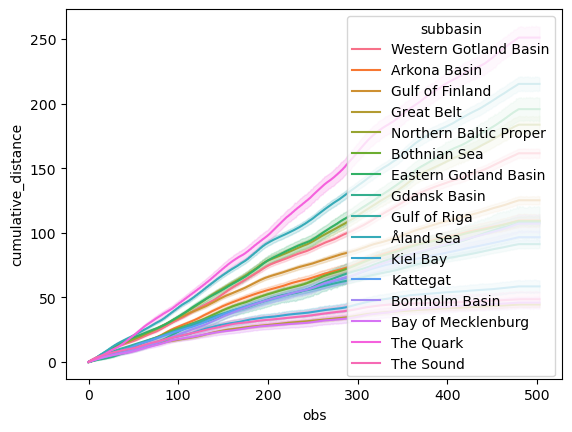

In [63]:
sns.lineplot(
        data=df, 
        x="obs", y="cumulative_distance",
        hue="subbasin",
)

<Axes: xlabel='total_distance', ylabel='subbasin'>

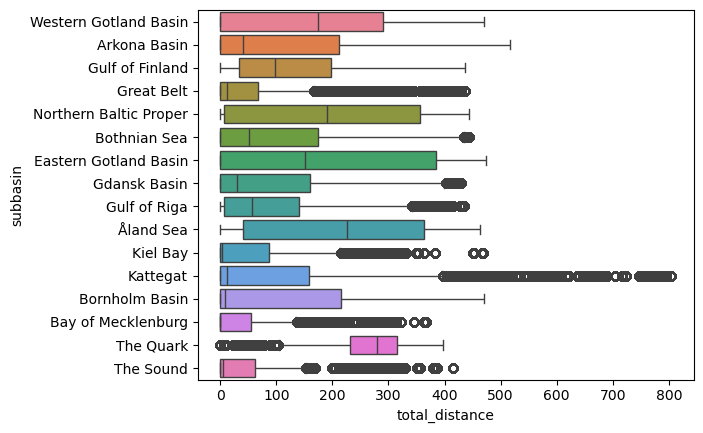

In [55]:
sns.boxplot(df, x="total_distance", y="subbasin", hue="subbasin")

In [58]:
# ds_trajectories.assign(count=
subbasin_grouped = ds_trajectories.groupby("subbasin")
basin_counts = np.array([
        [len(subbasin[1].trajectory), len(np.unique(subbasin[1].cell_code))]
        for subbasin in subbasin_grouped
])

In [59]:
basin_names = pd.Index(data=list(subbasin_grouped.groups.keys()), name="subbasins")
basin_idx = pd.Index(data=["trajs", "cells"], name="index")

In [60]:
basins = pd.DataFrame(
        index=basin_names,
        columns=basin_idx,
        data=basin_counts,
)

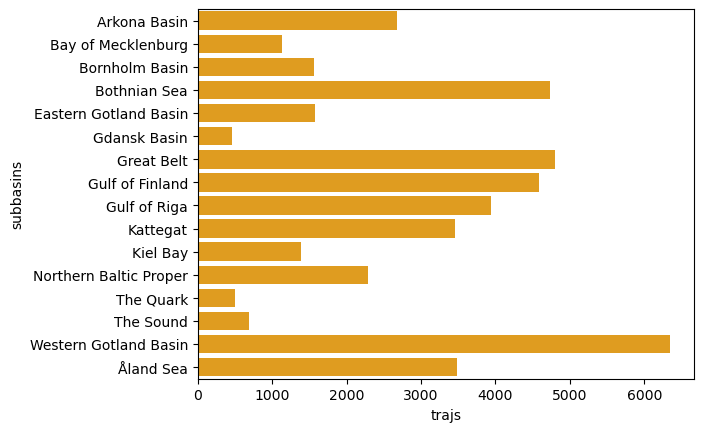

<Axes: xlabel='cells', ylabel='subbasins'>

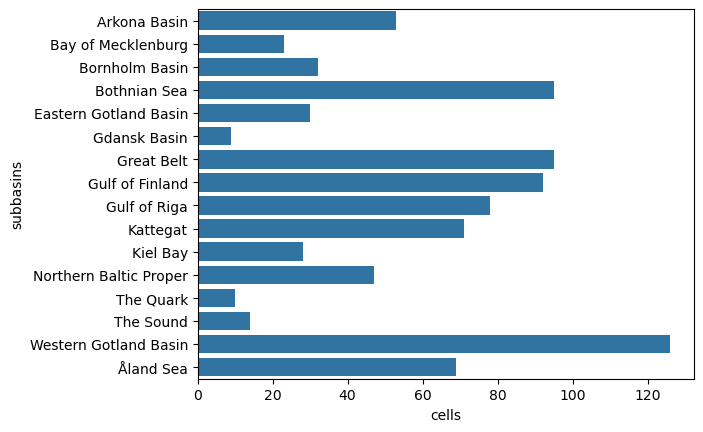

In [61]:
sns.barplot(basins, x="trajs", y="subbasins", color="orange")
plt.show()
sns.barplot(basins, x="cells", y="subbasins")

In [ ]:
mean_total_distance_per_cell = ds_trajectories.total_distance.groupby("cell_code").mean()
mean_total_distance_per_cell

In [ ]:
# open depth files and define depth cmap
path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
path_static_fine = path_static_files / "static_file_fine"
path_static_coarse = path_static_files / "static_file_coarse"
depth_coarse = xr.open_dataset(path_static_coarse / "H0_file_coarse.nc").H0
depth_fine = xr.open_dataset(path_static_fine / "H0_file_fine.nc").H0
cm_deep = cmocean.cm.deep

In [ ]:
traj_lat = np.concatenate(traj_moving.lat.values)
traj_lon = np.concatenate(traj_moving.lon.values)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]

In [ ]:
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*4, lat_range*4), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

In [ ]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
hm = ax.pcolormesh(
        xedges, yedges, hist.T, 
        cmap="inferno", norm=LogNorm(),
        transform=ccrs.PlateCarree(),
)
fig.colorbar(hm)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

In [ ]:
trajectory_IDs_per_start_month = [
        data.trajectory.values 
        for month, data 
        in list(traj_moving.isel(obs=0).groupby("time.month"))
]

In [ ]:
i=0
for month in trajectory_IDs_per_start_month:
        lons = traj_moving.sel(trajectory=month).lon.values
        lats = traj_moving.sel(trajectory=month).lat.values

        traj_lat = np.concatenate(lats)
        traj_lon = np.concatenate(lons)

        hist, xedges, yedges = np.histogram2d(
                x=traj_lon, y=traj_lat, 
                bins=(lon_range*4*2, lat_range*4*2), 
                range=[[lon_min, lon_max], [lat_min, lat_max]],
        )
        if i == 0:
                monthly_data = hist
                i =+ 1
        else:
                monthly_data = np.dstack((monthly_data, hist))
monthly_data.shape

In [ ]:
xedges, yedges = np.arange(lon_range*4*2), np.arange(lat_range*4*2)
da_monthly = xr.DataArray(
        data=monthly_data,
        coords=dict(
                lon=xedges,
                lat=yedges,
                month=np.arange(1,13),
        ),
        dims=["lon", "lat", "month"]
)

In [ ]:
da_monthly.plot(x="lon", y="lat", col="month", col_wrap=4, norm=LogNorm(vmin=1, vmax=1e4), cmap="inferno")


In [ ]:
obs_IDs_per_ten_days_of_age = [
        data.obs.values for age_10d, data in 
        list(traj_moving.isel(trajectory=0).groupby_bins(group="age_sec", bins=np.arange(0,221*60*60*24,10*60*60*24)))
]

In [ ]:
i=0
for obs in obs_IDs_per_ten_days_of_age:
        lons = traj_moving.isel(obs=obs).lon.values
        lats = traj_moving.isel(obs=obs).lat.values

        traj_lat = np.concatenate(lats)
        traj_lon = np.concatenate(lons)

        hist, xedges, yedges = np.histogram2d(
                x=traj_lon, y=traj_lat, 
                bins=(lon_range*4*2, lat_range*4*2), 
                range=[[lon_min, lon_max], [lat_min, lat_max]],
        )
        if i == 0:
                age_data = hist
                i =+ 1
        else:
                age_data = np.dstack((age_data, hist))
age_data.shape

In [ ]:
xedges, yedges = np.arange(lon_range*4*2), np.arange(lat_range*4*2)
da_age = xr.DataArray(
        data=age_data,
        coords=dict(
                lon=xedges,
                lat=yedges,
                obs=np.arange(0,220,10),
        ),
        dims=["lon", "lat", "obs"]
)

In [ ]:
da_age.plot(x="lon", y="lat", col="obs", col_wrap=5, norm=LogNorm(vmin=1, vmax=1e4), cmap="inferno")


In [ ]:
month = 4
lats = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lat.values
lons = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lon.values

traj_lat = np.concatenate(lats)
traj_lon = np.concatenate(lons)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*4*2, lat_range*4*2), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

latlon = np.meshgrid(xedges,yedges)


da_latlon = xr.DataArray(
        data=latlon[1].T,
        coords=dict(
                lat=yedges,
                lon=xedges,
        ),
        dims=["lon", "lat"]
)
da_latlon

In [ ]:
xr.plot.contour(latlon, x=traj_moving.lon, y=traj_moving.lat)

In [ ]:
month = 4
lats = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lat.values
lons = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lon.values

traj_lat = np.concatenate(lats)
traj_lon = np.concatenate(lons)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*4*2, lat_range*4*2), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
hm = ax.pcolormesh(
        xedges, yedges, hist.T, 
        cmap="inferno", norm=LogNorm(),
        transform=ccrs.PlateCarree(),
)
fig.colorbar(hm)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

In [ ]:
age_10days = 0
lats = traj_moving.isel(trajectory=obs_IDs_per_ten_days_of_age[age_10days]).lat.values
lons = traj_moving.isel(trajectory=obs_IDs_per_ten_days_of_age[age_10days]).lon.values

traj_lat = np.concatenate(lats)
traj_lon = np.concatenate(lons)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*8, lat_range*8), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
hm = ax.pcolormesh(
        xedges, yedges, hist.T, 
        cmap="inferno", norm=LogNorm(),
        transform=ccrs.PlateCarree(),
)
fig.colorbar(hm)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()